# Config 

Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
                                            low_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.944074  

Train samples: 460
Val samples:   116
Epoch [01/30] | Train Loss: 0.537243 | Val Loss: 0.412108 | Val MAE: 0.577604 | Val

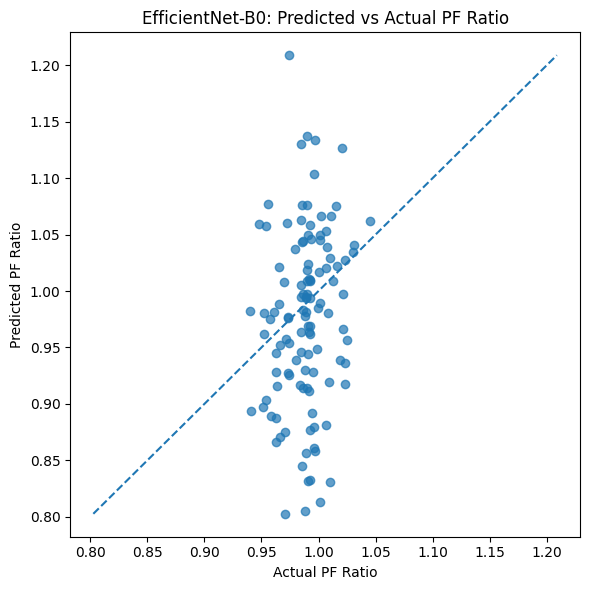


Model saved to: efficientnet_b0_dual_el_pf_ratio_from_AnonDB.pth


In [ ]:
import os
import math
import copy
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"          # original CSV file
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
RANDOM_SEED = 42
NUM_WORKERS = 0   # use 0 first, especially on Windows/Jupyter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """
    Convert relative paths like './EL/3903_35_1_01272020_20.tiff'
    into absolute paths based on the CSV/script directory.

    If add_wrp=True, convert:
    3903_35_1_01272020_20.tiff
    -> 3903_35_1_01272020_20_wrp.tiff
    """
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()

    if path_str == "":
        return None

    # Normalize slashes
    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    # Add _wrp before file extension if needed
    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    # If already absolute, keep it
    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    # Remove leading ./ if present
    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load original CSV, compute PF ratio, resolve paths, and
    keep only valid rows with existing low/high EL files.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELLPath", "ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    # Convert power columns to numeric safely
    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    # Remove invalid denominator
    df = df[df["Nameplate_Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"] > 0]

    # Remove invalid numerator
    df = df[df["Pmp_(W)"].notna()]

    # Compute PF ratio
    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    # Resolve actual paths
    df["low_path"] = df["ELLPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))

    # Remove missing path strings
    df = df[df["low_path"].notna()]
    df = df[df["high_path"].notna()]

    # Keep only rows whose image files actually exist
    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    # Keep only needed columns
    keep_cols = ["low_path", "high_path", "pf_ratio"]
    optional_id_cols = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep_cols = optional_id_cols + keep_cols

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# DATASET
# =========================================================
class DualELDataset(Dataset):
    def __init__(self, dataframe, image_size=224, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment

    def read_grayscale_tiff(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Failed to load image: {path}")

        return img

    def resize_image(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR #ini perlu dicek, tapi biasanya untuk EL images, linear sudah cukup
        )

    def apply_same_augmentation(self, low_img, high_img):
        """
        Keep augmentation identical for low/high pair.
        Keep it light for EL images.
        """
        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 1)
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 0)
            high_img = cv2.flip(high_img, 0)

        return low_img, high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        low_img = self.read_grayscale_tiff(row["low_path"])
        high_img = self.read_grayscale_tiff(row["high_path"])

        low_img = self.resize_image(low_img)
        high_img = self.resize_image(high_img)

        if self.augment:
            low_img, high_img = self.apply_same_augmentation(low_img, high_img)

        # Normalize to [0, 1]
        low_img = low_img.astype(np.float32) / 255.0
        high_img = high_img.astype(np.float32) / 255.0

        # [H, W] -> [1, H, W]
        low_img = np.expand_dims(low_img, axis=0)
        high_img = np.expand_dims(high_img, axis=0)

        # stack -> [2, H, W]
        x = np.concatenate([low_img, high_img], axis=0)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row["pf_ratio"], dtype=torch.float32)

        return x, y


# =========================================================
# MODEL
# =========================================================
def build_efficientnet_b0_2ch(pretrained=True):
    """
    EfficientNet-B0 modified to accept 2-channel input
    and output 1 regression value.
    """
    if pretrained:
        weights = models.EfficientNet_B0_Weights.DEFAULT
    else:
        weights = None

    model = models.efficientnet_b0(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        if pretrained:
            old_weights = old_conv.weight  # [out_channels, 3, k, k]

            # simple initialization using first 2 RGB channels
            new_conv.weight[:, 0, :, :] = old_weights[:, 0, :, :]
            new_conv.weight[:, 1, :, :] = old_weights[:, 1, :, :]
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 1)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, np.array(preds), np.array(trues)


# =========================================================
# MAIN
# =========================================================
def main():
    # -------------------------
    # Prepare dataframe
    # -------------------------
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 10:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    # -------------------------
    # Train / validation split
    # -------------------------
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")

    # -------------------------
    # Dataset / loader
    # -------------------------
    train_dataset = DualELDataset(train_df, image_size=IMAGE_SIZE, augment=True)
    val_dataset = DualELDataset(val_df, image_size=IMAGE_SIZE, augment=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # -------------------------
    # Model
    # -------------------------
    model = build_efficientnet_b0_2ch(pretrained=True).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    # -------------------------
    # Train loop
    # -------------------------
    for epoch in range(NUM_EPOCHS):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    # -------------------------
    # Final evaluation
    # -------------------------
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, preds, trues = evaluate(
        model, val_loader, criterion, DEVICE
    )

    print("\nBest Validation Performance")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    # -------------------------
    # Scatter plot: actual vs predicted
    # -------------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(trues, preds, alpha=0.7)

    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual PF Ratio")
    plt.ylabel("Predicted PF Ratio")
    plt.title("EfficientNet-B0: Predicted vs Actual PF Ratio")
    plt.tight_layout()
    plt.savefig("scatter_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
    plt.show()

    # -------------------------
    # Save model
    # -------------------------

    # -------------------------
    # Save model
    # -------------------------
    save_path = "efficientnet_b0_dual_el_pf_ratio_from_AnonDB.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to: {save_path}")


if __name__ == "__main__":
    main()

c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rows with valid power data before file filtering: 590
Rows with high-bias EL file existing: 584
Rows removed due to missing image file: 6

Sample rows:
                                          image_path  pf_ratio
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.944074

Train samples: 408
Val samples:   88
Test samples:  88

===== HYPERPARAMETER TUNING =====

--- Trial 1/8 ---
{'image_size': 224, 'batch_size': 16, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'dropout': 0.3, 'augment': True}


c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ghozy Abror\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Val MAE: 1.529739 | Val RMSE: 1.878698 | Val R2: -7743.006734

--- Trial 2/8 ---
{'image_size': 224, 'batch_size': 16, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'dropout': 0.2, 'augment': True}


Val MAE: 1.174423 | Val RMSE: 1.461463 | Val R2: -4685.268523

--- Trial 3/8 ---
{'image_size': 224, 'batch_size': 8, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'dropout': 0.3, 'augment': True}
Val MAE: 1.361616 | Val RMSE: 1.675563 | Val R2: -6158.896038

--- Trial 4/8 ---
{'image_size': 224, 'batch_size': 16, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'dropout': 0.3, 'augment': False}
Val MAE: 1.500458 | Val RMSE: 1.971720 | Val R2: -8528.866812

--- Trial 5/8 ---
{'image_size': 256, 'batch_size': 8, 'learning_rate': 0.0003, 'weight_decay': 1e-05, 'dropout': 0.2, 'augment': True}
Val MAE: 0.900117 | Val RMSE: 1.109508 | Val R2: -2699.927063

--- Trial 6/8 ---
{'image_size': 256, 'batch_size': 8, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'dropout': 0.2, 'augment': True}
Val MAE: 1.159701 | Val RMSE: 1.535440 | Val R2: -5171.698013

--- Trial 7/8 ---
{'image_size': 224, 'batch_size': 16, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'dropout': 0.3, 'augment': True}


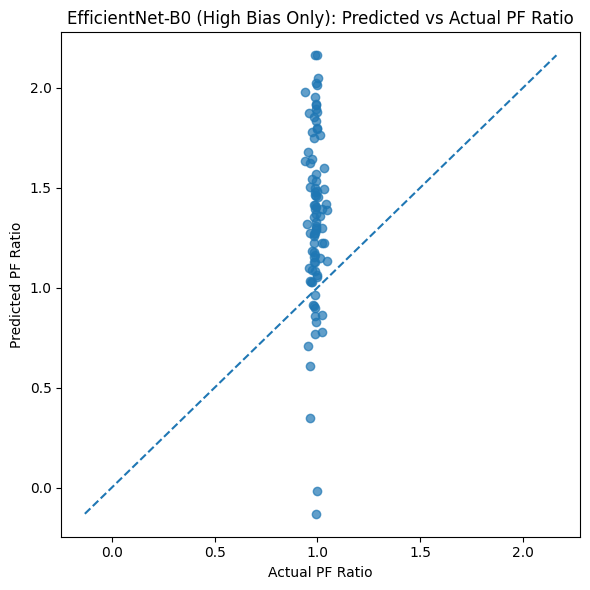

In [2]:
import os
import math
import copy
import random
import itertools
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"
RANDOM_SEED = 42
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# tuning settings
MAX_TRIALS = 8   # set smaller/larger depending on time
EPOCHS_PER_TRIAL = 15
FINAL_EPOCHS = 30

# search space
SEARCH_SPACE = {
    "image_size": [224, 256],
    "batch_size": [8, 16],
    "learning_rate": [1e-4, 3e-4],
    "weight_decay": [1e-4, 1e-5],
    "dropout": [0.2, 0.3],
    "augment": [False, True],
}


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """
    Convert paths like './EL/3903_35_1_01272020_80.tiff'
    into absolute paths based on CSV location.

    If add_wrp=True:
    3903_35_1_01272020_80.tiff
    -> 3903_35_1_01272020_80_wrp.tiff
    """
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if ext.lower() == ".tiff" and not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load AnonDB.csv, compute PF ratio, resolve HIGH-bias wrapped path,
    and keep only valid rows with existing image files.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df = df[df["Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"] > 0]

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    # only HIGH bias
    df["image_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir, add_wrp=True))
    df = df[df["image_path"].notna()]

    df["image_exists"] = df["image_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["image_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with high-bias EL file existing: {total_after}")
    print(f"Rows removed due to missing image file: {total_before - total_after}")

    keep_cols = ["image_path", "pf_ratio"]
    optional_id_cols = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep_cols = optional_id_cols + keep_cols

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# DATASET
# =========================================================
class SingleELDataset(Dataset):
    def __init__(self, dataframe, image_size=224, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment

    def read_grayscale_tiff(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to load image: {path}")
        return img

    def resize_image(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR
        )

    def apply_augmentation(self, img):
        # light augmentation only
        if random.random() < 0.5:
            img = cv2.flip(img, 1)

        if random.random() < 0.5:
            img = cv2.flip(img, 0)

        return img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = self.read_grayscale_tiff(row["image_path"])
        img = self.resize_image(img)

        if self.augment:
            img = self.apply_augmentation(img)

        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # [1, H, W]

        x = torch.tensor(img, dtype=torch.float32)
        y = torch.tensor(row["pf_ratio"], dtype=torch.float32)

        return x, y


# =========================================================
# MODEL
# =========================================================
def build_efficientnet_b0_1ch(dropout=0.2, pretrained=True):
    """
    EfficientNet-B0 from timm:
    - 1 input channel
    - 1 regression output
    """
    model = timm.create_model(
        "efficientnet_b0",
        pretrained=pretrained,
        in_chans=1,
        num_classes=1,
        drop_rate=dropout
    )
    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, np.array(preds), np.array(trues)


def run_training_trial(train_df, val_df, params, epochs, verbose=True):
    train_dataset = SingleELDataset(
        train_df,
        image_size=params["image_size"],
        augment=params["augment"]
    )
    val_dataset = SingleELDataset(
        val_df,
        image_size=params["image_size"],
        augment=False
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True,
        num_workers=NUM_WORKERS
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=params["batch_size"],
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    model = build_efficientnet_b0_1ch(
        dropout=params["dropout"],
        pretrained=True
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"]
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    history = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "val_r2": val_r2
        })

        if verbose:
            print(
                f"Epoch [{epoch+1:02d}/{epochs}] | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f} | "
                f"Val MAE: {val_mae:.6f} | "
                f"Val RMSE: {val_rmse:.6f} | "
                f"Val R2: {val_r2:.6f}"
            )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    final_val_loss, final_val_mae, final_val_rmse, final_val_r2, preds, trues = evaluate(
        model, val_loader, criterion, DEVICE
    )

    results = {
        "best_val_loss": final_val_loss,
        "best_val_mae": final_val_mae,
        "best_val_rmse": final_val_rmse,
        "best_val_r2": final_val_r2,
        "preds": preds,
        "trues": trues,
        "history": history,
        "model_state_dict": copy.deepcopy(model.state_dict())
    }

    return results


# =========================================================
# HYPERPARAMETER TUNING
# =========================================================
def sample_hyperparameter_configs(search_space, max_trials):
    keys = list(search_space.keys())
    all_combinations = list(itertools.product(*(search_space[k] for k in keys)))

    random.shuffle(all_combinations)
    selected = all_combinations[:max_trials]

    configs = []
    for combo in selected:
        cfg = dict(zip(keys, combo))
        configs.append(cfg)

    return configs


# =========================================================
# MAIN
# =========================================================
def main():
    # -------------------------
    # prepare dataframe
    # -------------------------
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    # -------------------------
    # split train / val / test
    # -------------------------
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=RANDOM_SEED
    )

    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.1765,  # gives about 15% of total
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # -------------------------
    # hyperparameter tuning
    # -------------------------
    configs = sample_hyperparameter_configs(SEARCH_SPACE, MAX_TRIALS)
    trial_results = []

    best_trial_rmse = float("inf")
    best_trial_params = None
    best_trial_model_state = None

    print("\n===== HYPERPARAMETER TUNING =====")
    for i, params in enumerate(configs, start=1):
        print(f"\n--- Trial {i}/{len(configs)} ---")
        print(params)

        results = run_training_trial(
            train_df=train_df,
            val_df=val_df,
            params=params,
            epochs=EPOCHS_PER_TRIAL,
            verbose=False
        )

        print(
            f"Val MAE: {results['best_val_mae']:.6f} | "
            f"Val RMSE: {results['best_val_rmse']:.6f} | "
            f"Val R2: {results['best_val_r2']:.6f}"
        )

        trial_row = params.copy()
        trial_row.update({
            "val_mae": results["best_val_mae"],
            "val_rmse": results["best_val_rmse"],
            "val_r2": results["best_val_r2"]
        })
        trial_results.append(trial_row)

        if results["best_val_rmse"] < best_trial_rmse:
            best_trial_rmse = results["best_val_rmse"]
            best_trial_params = params
            best_trial_model_state = copy.deepcopy(results["model_state_dict"])

    trials_df = pd.DataFrame(trial_results).sort_values("val_rmse")
    trials_df.to_csv("tuning_results_single_high_bias.csv", index=False)

    print("\n===== BEST HYPERPARAMETERS =====")
    print(best_trial_params)
    print(f"Best validation RMSE: {best_trial_rmse:.6f}")

    # -------------------------
    # final training on train+val
    # -------------------------
    print("\n===== FINAL TRAINING =====")
    final_train_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

    final_results = run_training_trial(
        train_df=final_train_df,
        val_df=test_df,   # evaluate on test here
        params=best_trial_params,
        epochs=FINAL_EPOCHS,
        verbose=True
    )

    print("\n===== TEST PERFORMANCE =====")
    print(f"Test MAE  : {final_results['best_val_mae']:.6f}")
    print(f"Test RMSE : {final_results['best_val_rmse']:.6f}")
    print(f"Test R2   : {final_results['best_val_r2']:.6f}")

    # -------------------------
    # save best model
    # -------------------------
    save_path = "efficientnet_b0_single_highbias_pf_ratio_tuned.pth"
    torch.save(final_results["model_state_dict"], save_path)
    print(f"\nModel saved to: {save_path}")

    # -------------------------
    # save predictions
    # -------------------------
    pred_df = pd.DataFrame({
        "actual_pf_ratio": final_results["trues"],
        "predicted_pf_ratio": final_results["preds"]
    })
    pred_df.to_csv("test_predictions_single_high_bias.csv", index=False)

    # -------------------------
    # scatter plot
    # -------------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(final_results["trues"], final_results["preds"], alpha=0.7)

    min_val = min(final_results["trues"].min(), final_results["preds"].min())
    max_val = max(final_results["trues"].max(), final_results["preds"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual PF Ratio")
    plt.ylabel("Predicted PF Ratio")
    plt.title("EfficientNet-B0 (High Bias Only): Predicted vs Actual PF Ratio")
    plt.tight_layout()
    plt.savefig("scatter_single_high_bias_pf_ratio.png", dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()